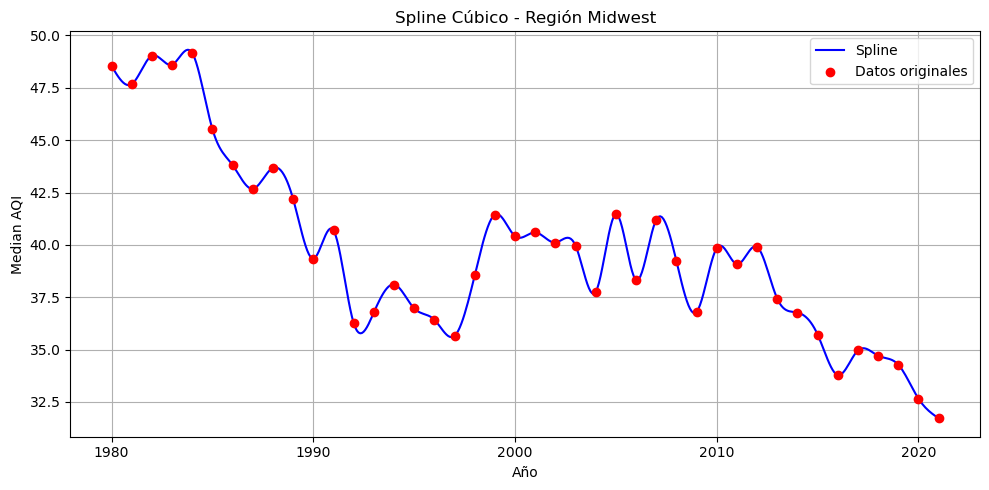

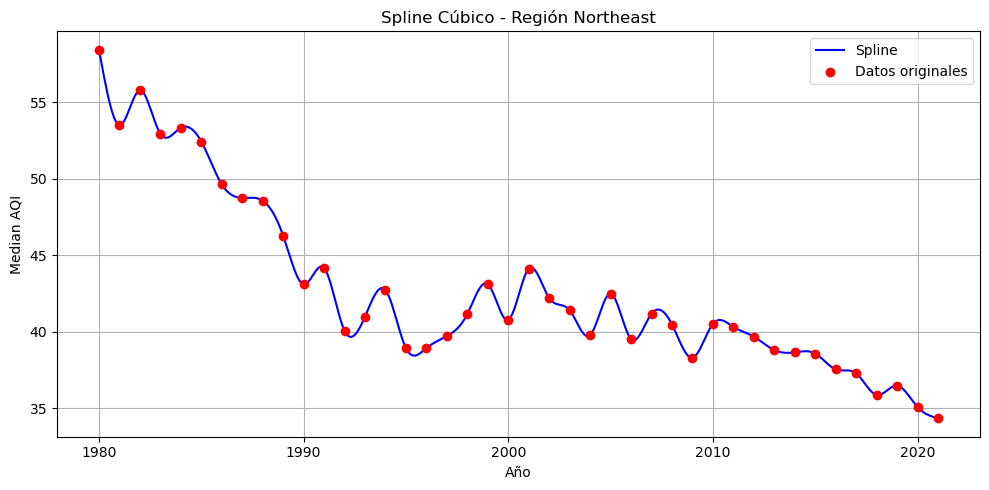

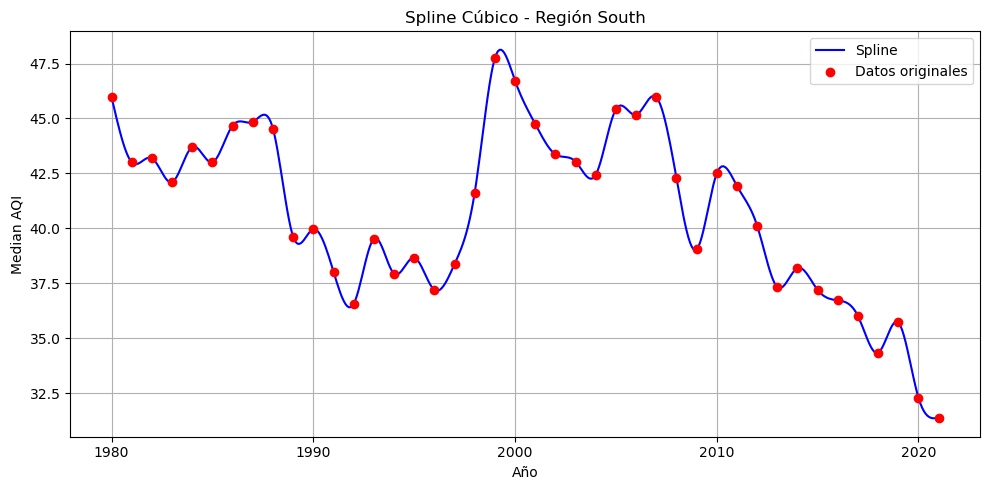

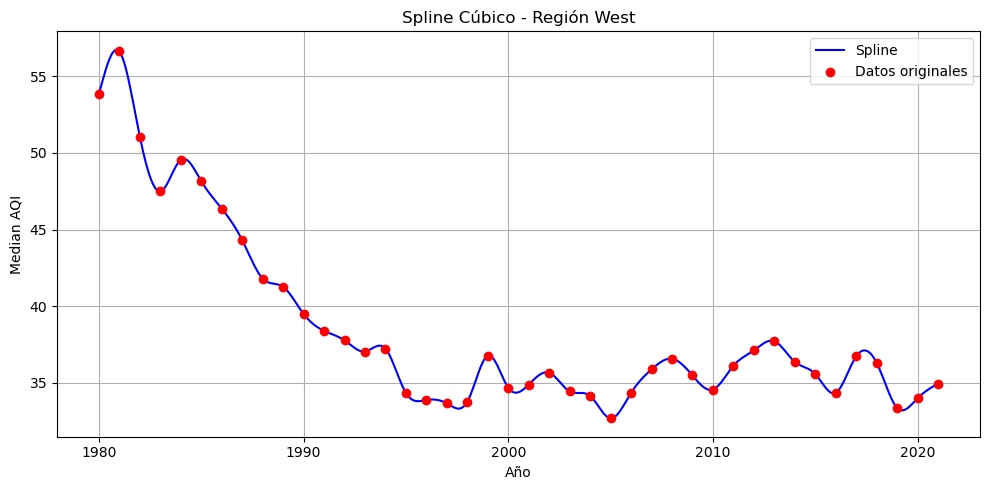

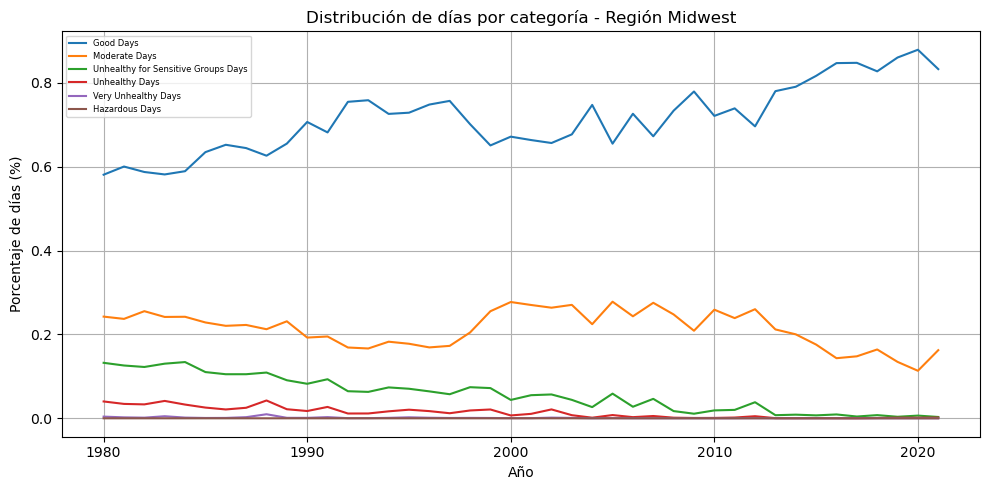

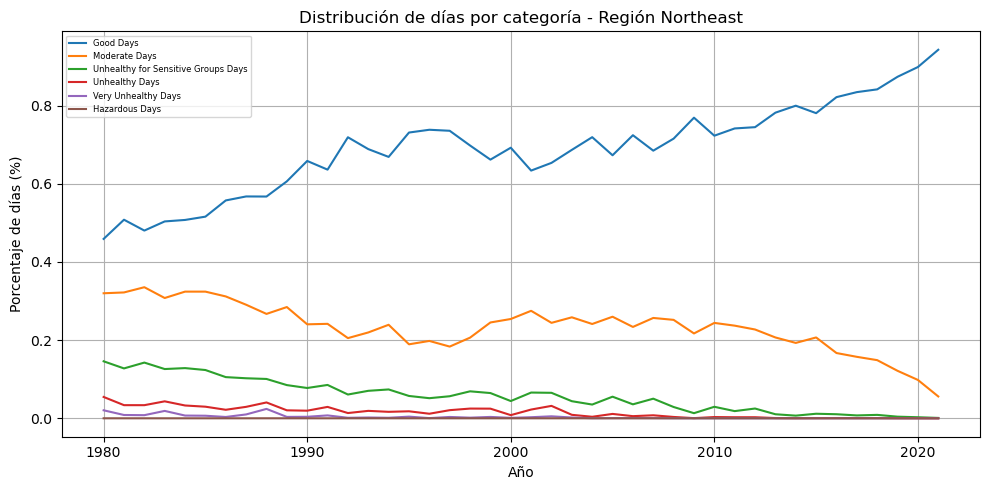

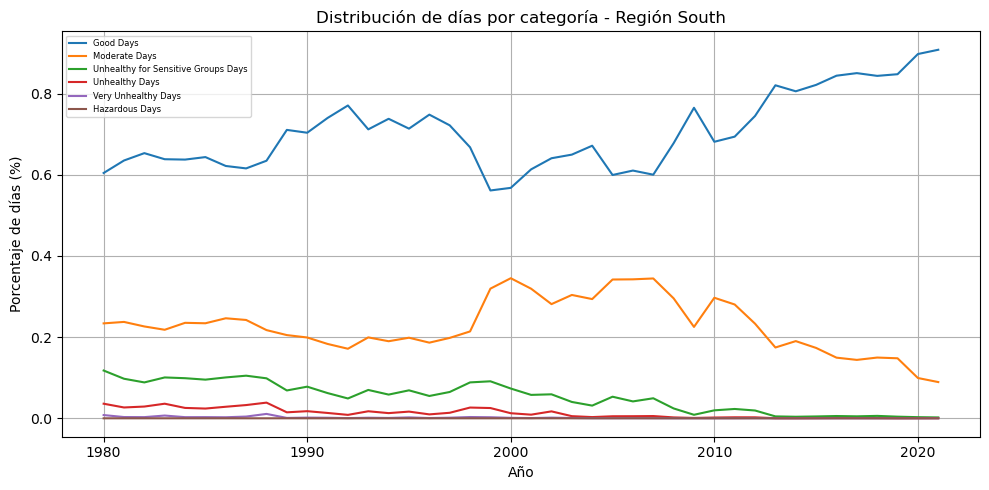

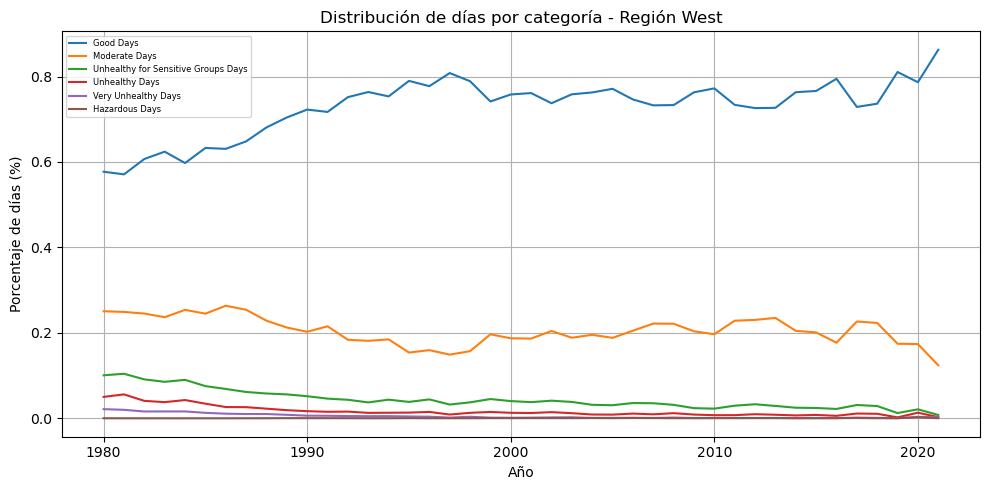

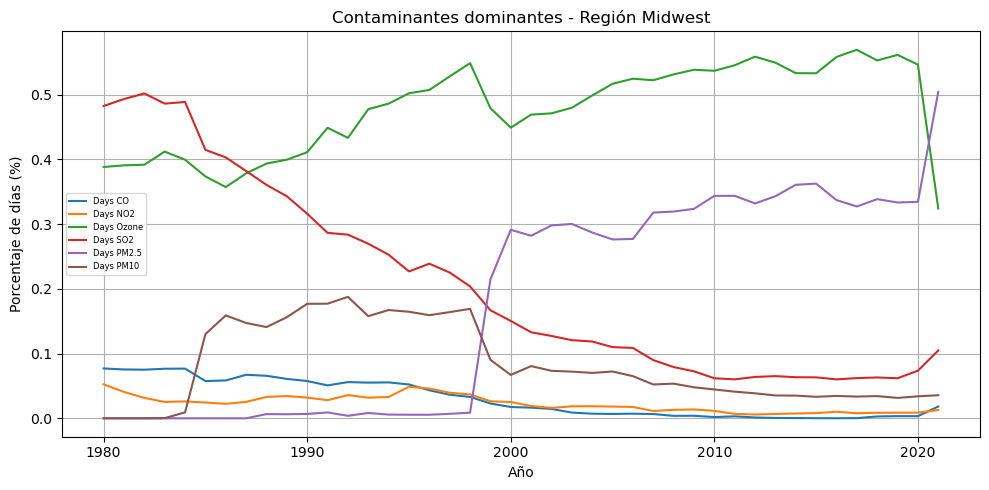

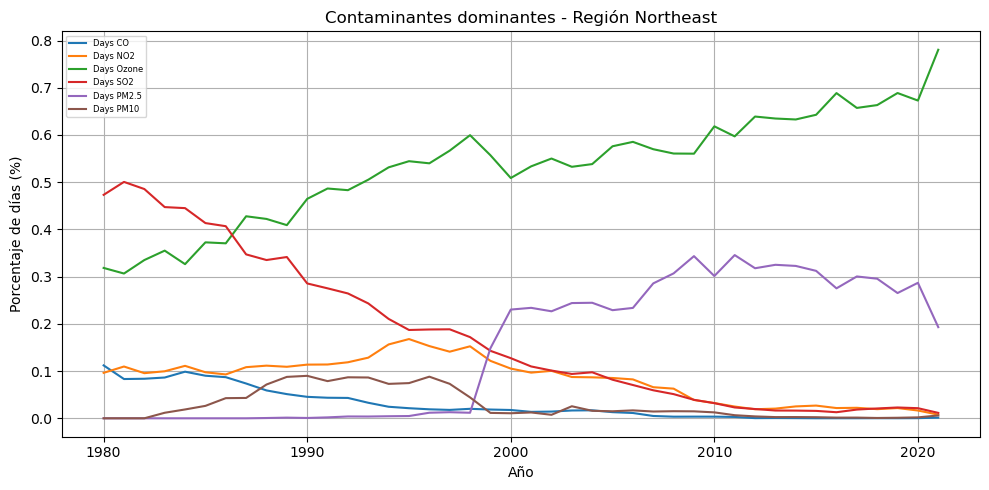

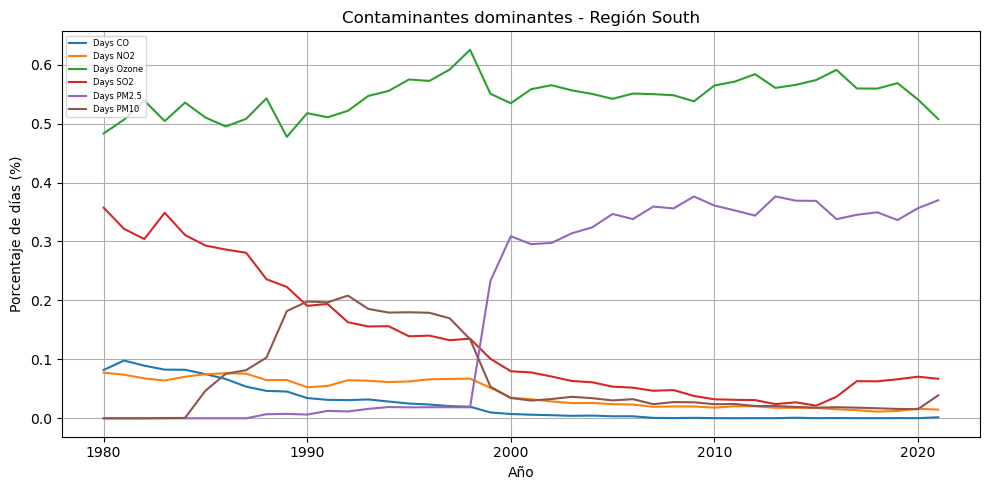

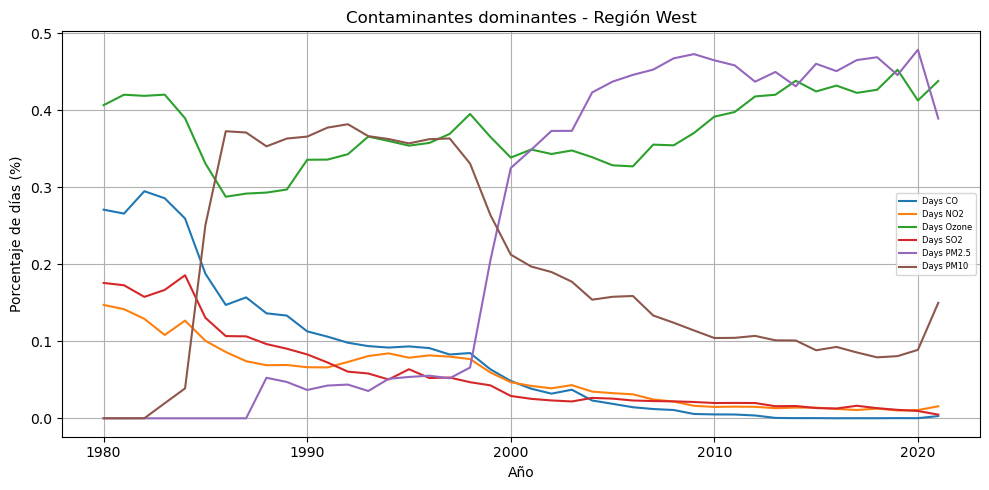

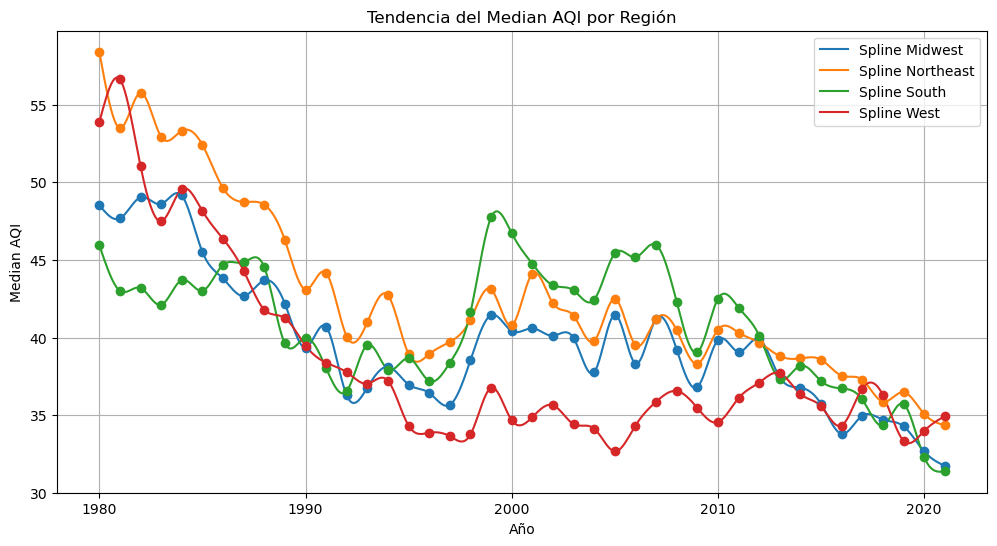

In [3]:
# Bibliotecas importadas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("../dataset/dataset_limpio.csv")


# Spline cúbico Natural

def splineNatural(n: int, x: list, a: list):
    """
    Realiza la interpolación por splines naturales para un conjunto de puntos iniciales.
    Los datos de tipo lista deben ingresarse como listas en sus respectivas variables.
    
    Args:
        n (int): Número de intervalos.
        x (list): Lista de puntos en el eje x.
        a (list): Lista de valores de la función evaluada en cada punto x.
    
    Returns:
        list[tuple]: Lista de tuplas con los coeficientes de cada polinomio del spline.
    
    Example:
        >>> x = [0, 1, 2]
        >>> a = [-5, -4, 3]
        >>> splineNatural(2, x, a)
        [(-5, -0.5, 0.0, 1.5), (-4, 4.0, 4.5, -1.5)]
    """

    h = [0] * n

    i = 0
    while i < n:
        h[i] = x[i+1] - x[i]
        i += 1

    alpha = [0] * n

    j = 1
    while j < n:
        alpha[j] = ((3 / h[j]) * (a[j+1] - a[j])) - \
                   ((3 / h[j-1]) * (a[j] - a[j-1]))
        j += 1

    l = [0] * (n + 1)
    u = [0] * (n + 1)
    z = [0] * (n + 1)

    l[0] = 1
    u[0] = 0
    z[0] = 0

    j = 1
    while j < n:

        l[j] = 2 * (x[j+1] - x[j-1]) - h[j-1] * u[j-1]
        u[j] = h[j] / l[j]
        z[j] = (alpha[j] - h[j-1] * z[j-1]) / l[j]
        j += 1

    b = [0] * n
    c = [0] * (n + 1)
    d = [0] * n

    l[n] = 1
    z[n] = 0
    c[n] = 0

    j = n - 1

    while j >= 0:

        c[j] = z[j] - u[j] * c[j+1]
        b[j] = ((a[j+1] - a[j]) / h[j]) - (h[j] * (c[j+1] + 2 * c[j]) / 3)
        d[j] = (c[j+1] - c[j]) / (3 * h[j])
        j -= 1

    resultado = []

    j = 0
    while j < n:

        resultado.append((a[j], b[j], c[j], d[j]))
        j += 1

    return resultado


# Evaluación del spline

def evaluarSpline(x_eval: float, x: list, coeficientes: list):
    """
    Evalúa el spline cúbico natural en un punto específico
    Los datos de tipo lista se ingresan como una lista en la variable respectiva

    Args:
        x_eval (float): Punto en el que se desea evaluar el spline.
        x (list): Lista de puntos en el eje x.
        coeficientes (list[tuple]): Lista de tuplas con los coeficientes de cada polinomio del spline.

    Returns:
        float: Valor del spline evaluado en x_eval.

    Example:
        >>> x_eval = 1.5
        >>> x = [0, 1, 2]
        >>> coeficientes = [
        ...     (-5, -0.5, 0.0, 1.5),
        ...     (-4, 4.0, 4.5, -1.5)
        ... ]
        >>> evaluar_spline(x_eval, x, coeficientes)
        0.625
    """

    n = len(coeficientes)

    for i in range(n):
        if x[i] <= x_eval <= x[i+1]:
            a, b, c, d = coeficientes[i]
            dx = x_eval - x[i]
            return a + b * dx + c * (dx**2) + d * (dx**3)

    raise ValueError("El punto de evaluación está fuera del rango de los datos")    

def graficar_spline_por_region(df):
    """
    Grafica el spline cúbico de cada región en una subgráfica separada.

    Args:
        df (DataFrame): Dataset limpio y agrupado por región y año.

    Returns:
        None
    """
    for region in df["Region"].unique():
        datos = df[df["Region"] == region].sort_values("Year")
        x = datos["Year"].tolist()
        y = datos["Median AQI"].tolist()
        n = len(x) - 1

        coeficientes = splineNatural(n, x, y)
        x_suavizado = np.linspace(min(x), max(x), 500)
        y_suavizado = [evaluarSpline(xi, x, coeficientes) for xi in x_suavizado]

        plt.figure(figsize=(10, 5))
        plt.plot(x_suavizado, y_suavizado, color="blue", label="Spline")
        plt.scatter(x, y, color="red", zorder=5, label="Datos originales")
        plt.title(f"Spline Cúbico - Región {region}")
        plt.xlabel("Año")
        plt.ylabel("Median AQI")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f"../graficas/spline_{region}.png")
        plt.show()  

def graficar_dias_por_region(df):
    """
    Grafica la distribución de días por categoría de AQI por región.

    Args:
        df (DataFrame): Dataset limpio y agrupado por región y año.

    Returns:
        None
    """
    dias = ['Good Days', 'Moderate Days', 'Unhealthy for Sensitive Groups Days',
                     'Unhealthy Days', 'Very Unhealthy Days', 'Hazardous Days']

    for region in df['Region'].unique():
        datos = df[df['Region'] == region].sort_values('Year')
        años = datos['Year'].tolist()

        plt.figure(figsize=(10, 5))
        for col in dias:
            plt.plot(años, datos[col].tolist(), label=col)

        plt.title(f'Distribución de días por categoría - Región {region}')
        plt.xlabel('Año')
        plt.ylabel('Porcentaje de días (%)')
        plt.legend(fontsize=6)
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f'../graficas/dias_{region}.png')
        plt.show()

def graficar_contaminantes_por_region(df):
    """
    Grafica el porcentaje de días dominados por cada contaminante por región.

    Args:
        df (DataFrame): Dataset limpio y agrupado por región y año.

    Returns:
        None
    """
    contaminantes = ['Days CO', 'Days NO2', 'Days Ozone','Days SO2', 'Days PM2.5', 'Days PM10']

    for region in df['Region'].unique():
        datos = df[df['Region'] == region].sort_values('Year')
        años = datos['Year'].tolist()

        plt.figure(figsize=(10, 5))
        for col in contaminantes:
            plt.plot(años, datos[col].tolist(), label=col)

        plt.title(f'Contaminantes dominantes - Región {region}')
        plt.xlabel('Año')
        plt.ylabel('Porcentaje de días (%)')
        plt.legend(fontsize=6)
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f'../graficas/contaminantes_{region}.png')
        plt.show()

def graficar_spline_combinado(df):
    """
    Grafica los datos originales y la curva del spline cúbico natural para todas las regiones

    Args:
        df (DataFrame): Dataset limpio y agrupado por región y año.

    Returns:
        None
    """
    plt.figure(figsize=(12, 6))

    for region in df["Region"].unique():
        datos = df[df["Region"] == region].sort_values("Year")
        x = datos["Year"].tolist()
        y = datos["Median AQI"].tolist()
        n = len(x) - 1

        coeficientes = splineNatural(n, x, y)

        x_suavizado = np.linspace(min(x), max(x), 500)
        y_suavizado = [evaluarSpline(xi, x, coeficientes) for xi in x_suavizado]

        plt.plot(x_suavizado, y_suavizado, label=f"Spline {region}")
        plt.scatter(x, y, zorder=5)

    plt.title("Tendencia del Median AQI por Región")
    plt.xlabel("Año")
    plt.ylabel("Median AQI")
    plt.legend()
    plt.grid(True)
    plt.savefig("../graficas/spline_combinado.png")
    plt.show()
    
graficar_spline_por_region(df)
graficar_dias_por_region(df)
graficar_contaminantes_por_region(df)
graficar_spline_combinado(df)